In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def ma_crossover_strategy(data, fast_window=5, slow_window=20) -> pd.DataFrame:
    """
    Function that encapsulates our trading strategy of comparing two rolling average windows to decide market positions.
    Args:
        data (pd.DataFrame): DataFrame containing at least a 'Close' column with stock prices.
        fast_window (int): Window size for the fast moving average.
        slow_window (int): Window size for the slow moving average.
    Returns:
        pd.DataFrame: Original DataFrame with additional columns for Fast_MA, Slow_MA, Signal, and Entry_Exit.
    """

    # We work on a copy to avoid changing the original data
    df = data.copy()
    
    # Step 1: Calculate Moving Averages
    df['Fast_MA'] = df['Close'].rolling(window=fast_window).mean()
    df['Slow_MA'] = df['Close'].rolling(window=slow_window).mean()
    
    # Step 2: Define the Market State (1 for Bull/Long, 0 for Bear/Cash)
    # We use 0 instead of -1 if we just want to step out of the market rather than "shorting" it
    df['Signal'] = np.where(df['Fast_MA'] > df['Slow_MA'], 1, 0)
    
    # Step 3: Identify the Crossovers (The "Action" moments)
    # This helps us see exactly when the strategy decides to buy or sell
    df['Entry_Exit'] = df['Signal'].diff() # 1 indicates a buy signal, -1 indicates a sell signal


    # Step 4: Calculate the Open and Closing percentage returns
    df['Open_Returns'] = df['Open'].pct_change()
    df['Close_Returns'] = df['Close'].pct_change()

    # Step 5: Calculate the returns based on the strategy
    # When we get a buy signal (at the end of a day), we can buy at the open of the next day
    # and sell at the open of the next-to-next day if we get the sell signal. Therefore we have to shift the signals by 2.
    df['Strategy_Returns'] = df['Signal'].shift(2) * df['Open_Returns']

    # Clean up
    df.dropna(inplace=True)  # Remove any rows with NaN values resulting from calculations

    # Compute the returns
    df['Cumulative_Market_Returns'] = (1 + df['Close_Returns']).cumprod() - 1
    df['Cumulative_Strategy_Returns'] = (1 + df['Strategy_Returns']).cumprod() - 1
    
    return df

Right now, our strategy looks at the evolution of the daily closing prices and calculates whether the short average is above or below the long average, thereby deciding whether we should buy stocks (a positive crossover), hold stocks (no crossover) or sell stocks (negative crossover). However, if we decide to buy stocks, this can only be done on the oping price the next day (otherwise we incorporate a looking-forward-bias). 

In [2]:
# Import the Apple stock as example data
import yfinance as yf

apple_data = yf.download('AAPL', start='2020-01-01', end='2026-01-01')
apple_data.columns = apple_data.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [3]:
stategy_data = ma_crossover_strategy(apple_data)

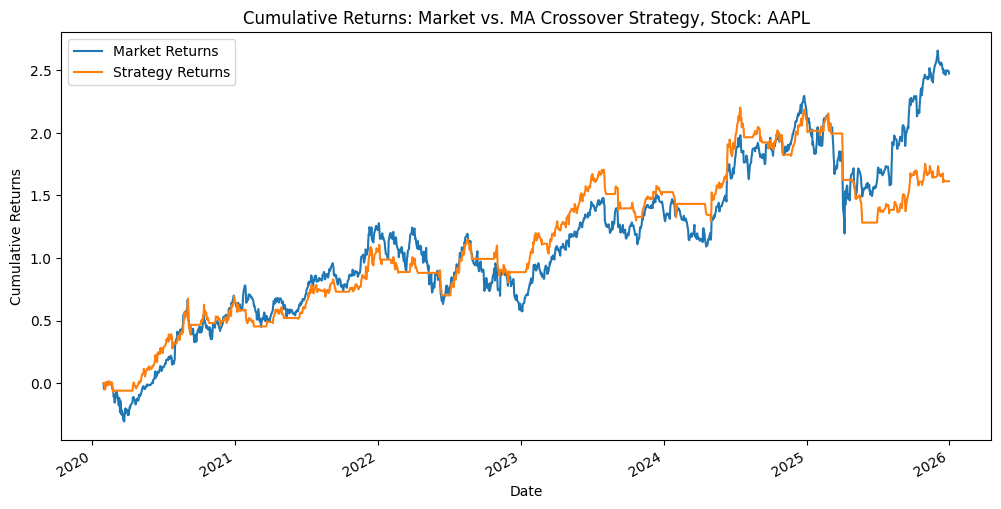

In [4]:
stategy_data['Cumulative_Market_Returns'].plot(label='Market Returns', figsize=(12,6))
stategy_data['Cumulative_Strategy_Returns'].plot(label='Strategy Returns')
plt.title('Cumulative Returns: Market vs. MA Crossover Strategy, Stock: AAPL')
plt.ylabel('Cumulative Returns')
plt.xlabel('Date')
plt.legend()
plt.show()

To quantify the data, we want to look at the stategy and market returns, the volatility and the sharpe ratio. The latter is the ratio of the difference of return of invest of the stategy vs. a risk free asset divided by the volatility of the asset:
$$S_a=\frac{E(R_a-R_b)}{\sigma_a}$$

In [5]:
def generate_metric(df: pd.DataFrame) -> dict:
    """
    Generate performance metrics for the trading strategy.
    Args:
        df (pd.DataFrame): DataFrame containing 'Cumulative_Market_Returns' and 'Cumulative_Strategy_Returns'.
    Returns:
        dict: Dictionary containing total returns and outperformance.
    """
    days = len(df)
    years = days / 252  # Approximate number of trading days in a year

    total_market_return = df['Cumulative_Market_Returns'].iloc[-1]
    annualized_market_return = (1 + total_market_return) ** (1 / years) - 1
    market_volatility = df['Close_Returns'].std() * np.sqrt(252)  # Annualized volatility
    total_strategy_return = df['Cumulative_Strategy_Returns'].iloc[-1]
    annualized_strategy_return = (1 + total_strategy_return) ** (1 / years) - 1
    strategy_volatility = df['Strategy_Returns'].std() * np.sqrt(252)  # Annualized volatility
    total_outperformance = total_strategy_return - total_market_return
    annualized_outperformance = (1 + total_outperformance) ** (1 / years) - 1
    sharp_ratio = (annualized_strategy_return - annualized_market_return) / strategy_volatility if strategy_volatility != 0 else np.nan

    metrics = {
        'Total Market Return': total_market_return,
        'Annualized Market Return': annualized_market_return,
        'Market Volatility': market_volatility,
        'Total Strategy Return': total_strategy_return,
        'Annualized Strategy Return': annualized_strategy_return,
        'Strategy Volatility': strategy_volatility,
        'Total Outperformance': total_outperformance,
        'Annualized Outperformance': annualized_outperformance,
        'Sharpe Ratio': sharp_ratio,
        'Stategy Return vs Volatility': annualized_strategy_return / strategy_volatility if strategy_volatility != 0 else np.nan,
        'Market Return vs Volatility': annualized_market_return / market_volatility if market_volatility != 0 else np.nan,
    }
    
    return metrics

In [6]:
metric_dict = generate_metric(stategy_data)
for key, value in metric_dict.items():
    print(f"{key}: {value:.2%}")


Total Market Return: 247.40%
Annualized Market Return: 23.46%
Market Volatility: 31.90%
Total Strategy Return: 161.31%
Annualized Strategy Return: 17.65%
Strategy Volatility: 21.23%
Total Outperformance: -86.09%
Annualized Outperformance: -28.38%
Sharpe Ratio: -27.37%
Stategy Return vs Volatility: 83.16%
Market Return vs Volatility: 73.55%


Now lets get down and apply this to a list of stocks. We will look at a list defined by the 'Ticker' name below (like the 'AAPL' for Apple). We download the data from `yfinance`, apply our stategy to it using `ma_crossover_strategy` and finally gauge our results using `generate_metric`. We store all the data and can then finally look at it.

In [7]:
# Define the list of stocks to look at
# The top stocks
# ticker_names = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'JPM', 'SPY']

# A mix of Retail, Tech, Energy, and Industrial mid-caps
ticker_names = [
    # --- Consumer & Retail ---
    'CROX',  # Crocs Inc.
    'ANF',   # Abercrombie & Fitch
    'YETI',  # YETI Holdings
    'DKNG',  # DraftKings Inc.
    'RH',    # RH (Restoration Hardware)
    
    # --- Tech & Software (High Beta) ---
    'TWLO',  # Twilio Inc.
    'DOCU',  # DocuSign
    'DBX',   # Dropbox
    'ROKU',  # Roku Inc.
    'NET',   # Cloudflare
    
    # --- Energy & Solar ---
    'FSLR',  # First Solar
    'PLUG',  # Plug Power
    'RUN',   # Sunrun
    'OXY',   # Occidental Petroleum
    
    # --- Industrials & Materials ---
    'CLF',   # Cleveland-Cliffs (Steel)
    'AA',    # Alcoa Corp
    
    # --- Financials & Real Estate ---
    'OPEN',  # Opendoor Technologies
    'SOFI',  # SoFi Technologies
]

# Store the results in this dictionary
portfolio_results = {}
metric_results = {}

for ticker in ticker_names:
    try:
        print(f"Processing ticker: {ticker}")
        # Download stock data
        stock_data = yf.download(ticker, start='2020-01-01', end='2026-01-01')
        stock_data.columns = stock_data.columns.get_level_values(0)
        
        # Apply the strategy
        strategy_data = ma_crossover_strategy(stock_data)
        
        # Store the strategy data
        portfolio_results[ticker] = strategy_data
        
        # Generate and store metrics
        metrics = generate_metric(strategy_data)
        metric_results[ticker] = metrics
    except Exception as e:
        print(f"Error processing {ticker}: {e}")

[*********************100%***********************]  1 of 1 completed

Processing ticker: CROX
Processing ticker: ANF



[*********************100%***********************]  1 of 1 completed
/var/folders/w_/8ngsxkg11bq63bkdl4c47wvh0000gn/T/ipykernel_9041/1358395734.py:19: RuntimeWarning: invalid value encountered in scalar power
  annualized_outperformance = (1 + total_outperformance) ** (1 / years) - 1
[*********************100%***********************]  1 of 1 completed


Processing ticker: YETI
Processing ticker: DKNG


[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed


Processing ticker: AA


[*********************100%***********************]  1 of 1 completed
/var/folders/w_/8ngsxkg11bq63bkdl4c47wvh0000gn/T/ipykernel_9041/1358395734.py:19: RuntimeWarning: invalid value encountered in scalar power
  annualized_outperformance = (1 + total_outperformance) ** (1 / years) - 1
[*********************100%***********************]  1 of 1 completed


Processing ticker: OPEN
Processing ticker: SOFI


[*********************100%***********************]  1 of 1 completed


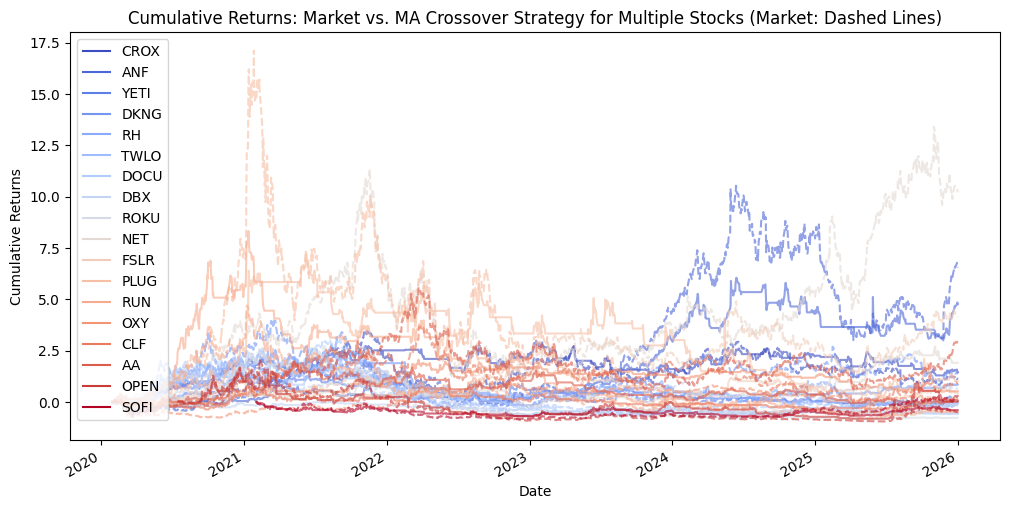

In [8]:
# Generate a color for every ticker
colors = plt.get_cmap('coolwarm', len(ticker_names))

for i, ticker in enumerate(ticker_names):
    portfolio_data = portfolio_results[ticker]
    portfolio_data['Cumulative_Market_Returns'].plot(color=colors(i), figsize=(12,6), alpha=0.6, linestyle='--', label='_nolegend_')
    portfolio_data['Cumulative_Strategy_Returns'].plot(color=colors(i), alpha = 0.6, label='_nolegend_')
    # Dummy plot for legend
    plt.plot([], [], color=colors(i), label=f'{ticker}')
plt.title('Cumulative Returns: Market vs. MA Crossover Strategy for Multiple Stocks (Market: Dashed Lines)')
plt.ylabel('Cumulative Returns')
plt.xlabel('Date')
plt.legend()
# plt.yscale('log')
plt.show()

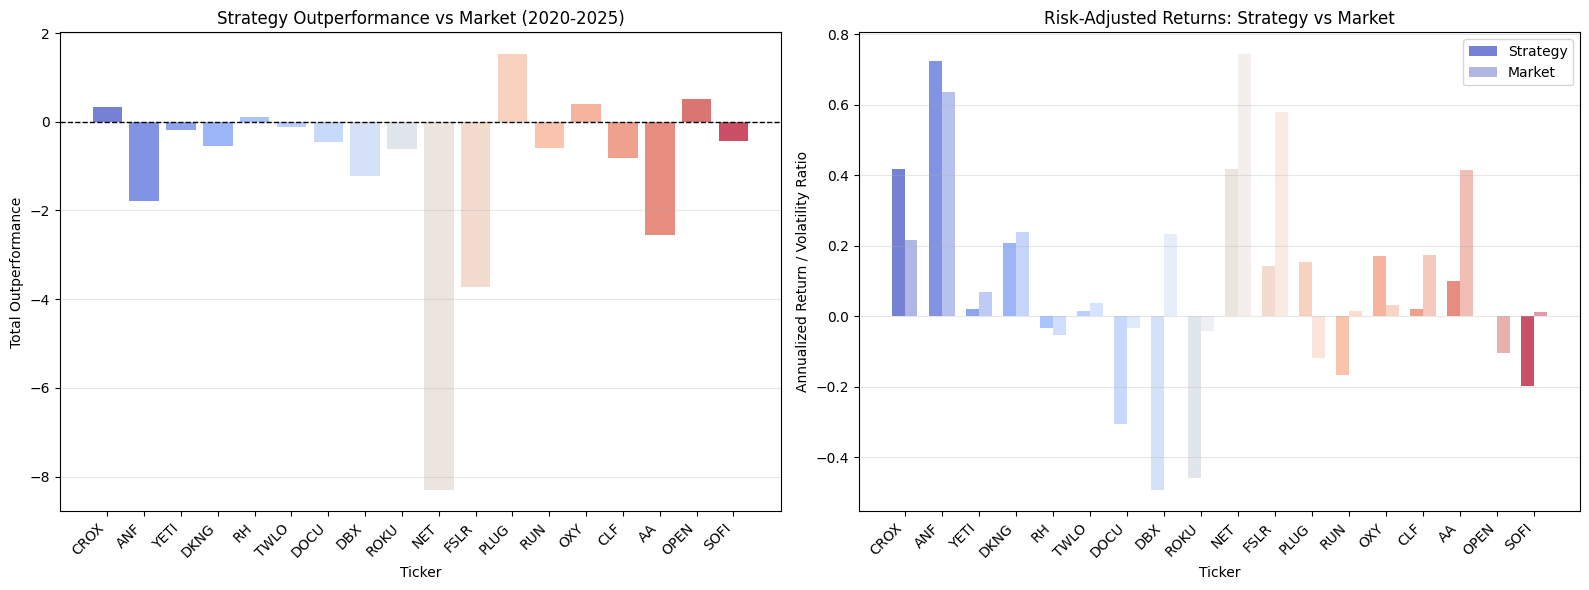

In [9]:
# Create subplots for outperformance and ROI-vs-volatility ratio
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Extract metrics for plotting
outperformance = [metric_results[ticker]['Total Outperformance'] for ticker in ticker_names]
roi_volatility_strategy = [metric_results[ticker]['Stategy Return vs Volatility'] for ticker in ticker_names]
roi_volatility_market = [metric_results[ticker]['Market Return vs Volatility'] for ticker in ticker_names]

x_pos = np.arange(len(ticker_names))

# Plot 1: Total Outperformance
ax1.bar(x_pos, outperformance, color=[colors(i) for i in range(len(ticker_names))], alpha=0.7)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('Ticker')
ax1.set_ylabel('Total Outperformance')
ax1.set_title('Strategy Outperformance vs Market (2020-2025)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(ticker_names, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: ROI vs Volatility Ratio (Annualized)
width = 0.35
ax2.bar(x_pos - width/2, roi_volatility_strategy, width, label='Strategy', 
    color=[colors(i) for i in range(len(ticker_names))], alpha=0.7)
ax2.bar(x_pos + width/2, roi_volatility_market, width, label='Market', 
    color=[colors(i) for i in range(len(ticker_names))], alpha=0.4)
ax2.set_xlabel('Ticker')
ax2.set_ylabel('Annualized Return / Volatility Ratio')
ax2.set_title('Risk-Adjusted Returns: Strategy vs Market')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(ticker_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

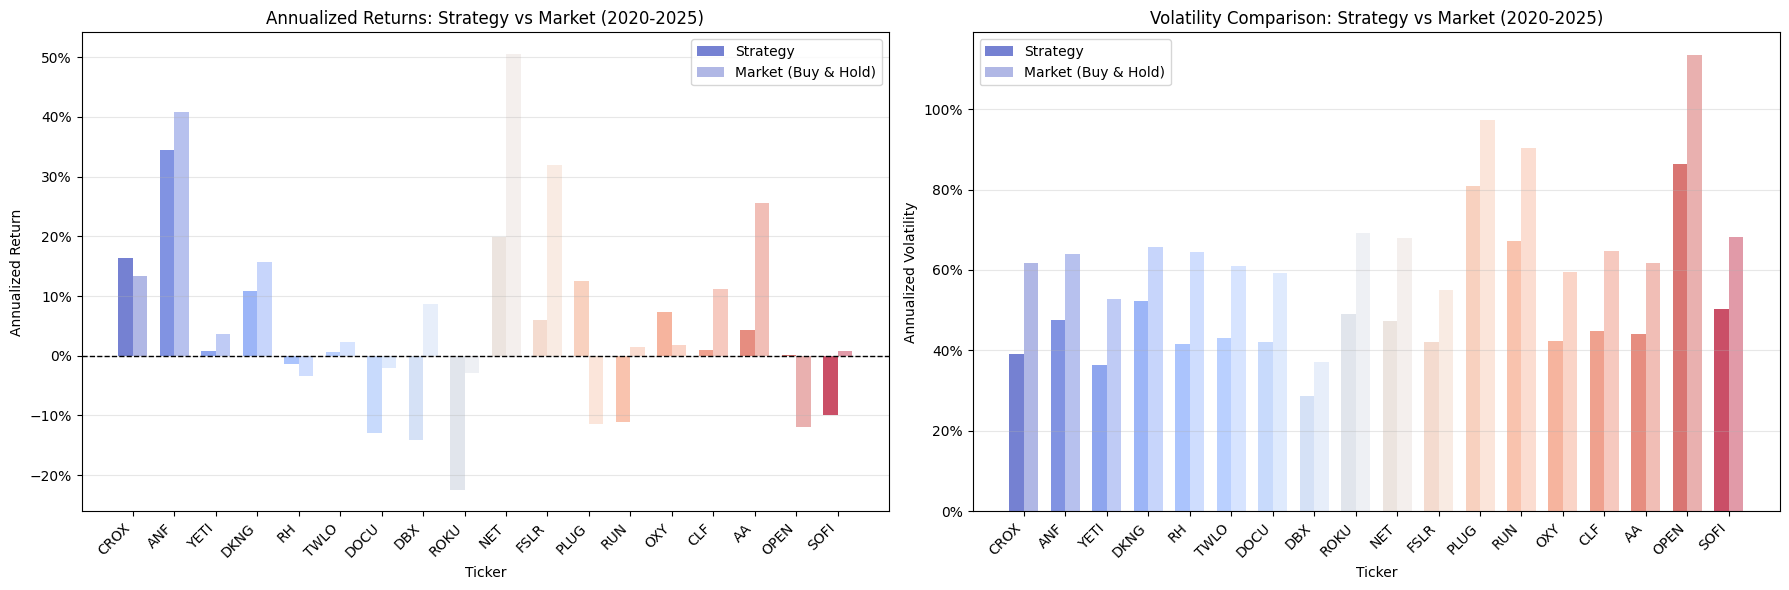


RETURNS SUMMARY
Profitable stocks (Strategy): 12/18
Profitable stocks (Market): 13/18

Average annualized return (Strategy): 2.35%
Average annualized return (Market): 9.80%

Best strategy performer: ANF (34.48%)
Best market performer: NET (50.53%)

Worst strategy performer: ROKU (-22.43%)
Worst market performer: OPEN (-11.92%)

VOLATILITY SUMMARY
Stocks with lower strategy volatility: 18/18

Average volatility (Strategy): 49.19%
Average volatility (Market): 67.39%

Lowest strategy volatility: DBX (28.77%)
Highest strategy volatility: OPEN (86.44%)


In [10]:
# Plot Annualized Returns and Volatility Comparison side by side
from matplotlib.ticker import PercentFormatter
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

annualized_strategy_returns = [metric_results[ticker]['Annualized Strategy Return'] for ticker in ticker_names]
annualized_market_returns = [metric_results[ticker]['Annualized Market Return'] for ticker in ticker_names]
strategy_volatility = [metric_results[ticker]['Strategy Volatility'] for ticker in ticker_names]
market_volatility = [metric_results[ticker]['Market Volatility'] for ticker in ticker_names]
x_pos = np.arange(len(ticker_names))
width = 0.35

# Plot 1: Annualized Returns
bars1 = ax1.bar(x_pos - width/2, annualized_strategy_returns, width, label='Strategy', 
               color=[colors(i) for i in range(len(ticker_names))], alpha=0.7)
bars2 = ax1.bar(x_pos + width/2, annualized_market_returns, width, label='Market (Buy & Hold)', 
               color=[colors(i) for i in range(len(ticker_names))], alpha=0.4)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('Ticker')
ax1.set_ylabel('Annualized Return')
ax1.set_title('Annualized Returns: Strategy vs Market (2020-2025)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(ticker_names, rotation=45, ha='right')
ax1.yaxis.set_major_formatter(PercentFormatter(1))
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Volatility Comparison
bars3 = ax2.bar(x_pos - width/2, strategy_volatility, width, label='Strategy', 
               color=[colors(i) for i in range(len(ticker_names))], alpha=0.7)
bars4 = ax2.bar(x_pos + width/2, market_volatility, width, label='Market (Buy & Hold)', 
               color=[colors(i) for i in range(len(ticker_names))], alpha=0.4)
ax2.set_xlabel('Ticker')
ax2.set_ylabel('Annualized Volatility')
ax2.set_title('Volatility Comparison: Strategy vs Market (2020-2025)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(ticker_names, rotation=45, ha='right')
ax2.yaxis.set_major_formatter(PercentFormatter(1))
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print combined summary statistics
profitable_strategy_count = sum(1 for r in annualized_strategy_returns if r > 0)
profitable_market_count = sum(1 for r in annualized_market_returns if r > 0)
lower_volatility_count = sum(1 for i in range(len(ticker_names)) if strategy_volatility[i] < market_volatility[i])

print(f"\n{'='*60}")
print(f"RETURNS SUMMARY")
print(f"{'='*60}")
print(f"Profitable stocks (Strategy): {profitable_strategy_count}/{len(ticker_names)}")
print(f"Profitable stocks (Market): {profitable_market_count}/{len(ticker_names)}")
print(f"\nAverage annualized return (Strategy): {np.mean(annualized_strategy_returns):.2%}")
print(f"Average annualized return (Market): {np.mean(annualized_market_returns):.2%}")
print(f"\nBest strategy performer: {ticker_names[np.argmax(annualized_strategy_returns)]} ({max(annualized_strategy_returns):.2%})")
print(f"Best market performer: {ticker_names[np.argmax(annualized_market_returns)]} ({max(annualized_market_returns):.2%})")
print(f"\nWorst strategy performer: {ticker_names[np.argmin(annualized_strategy_returns)]} ({min(annualized_strategy_returns):.2%})")
print(f"Worst market performer: {ticker_names[np.argmin(annualized_market_returns)]} ({min(annualized_market_returns):.2%})")

print(f"\n{'='*60}")
print(f"VOLATILITY SUMMARY")
print(f"{'='*60}")
print(f"Stocks with lower strategy volatility: {lower_volatility_count}/{len(ticker_names)}")
print(f"\nAverage volatility (Strategy): {np.mean(strategy_volatility):.2%}")
print(f"Average volatility (Market): {np.mean(market_volatility):.2%}")
print(f"\nLowest strategy volatility: {ticker_names[np.argmin(strategy_volatility)]} ({min(strategy_volatility):.2%})")
print(f"Highest strategy volatility: {ticker_names[np.argmax(strategy_volatility)]} ({max(strategy_volatility):.2%})")